# Tornando visual
Esses códigos abaixo fornecem uma estimativa visual em tempo real de como estão acontecendo as mudanças de pesos e bias para que as ativações dos neurônios sejam feitas e tragam o resultado esperado.


Animação salva como 'neuron_weights_animation.gif'.


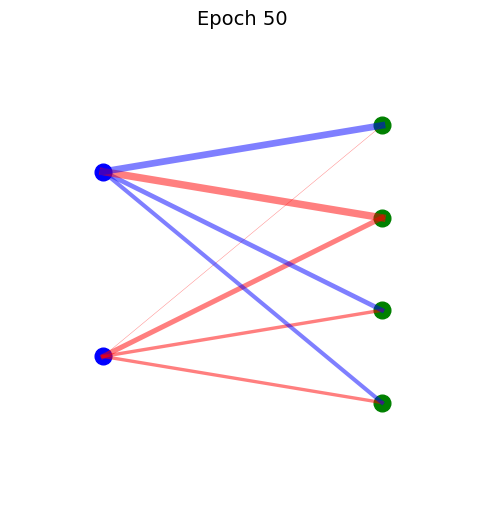

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Gerar dados sintéticos
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Criar modelo simples
model = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='tanh', name='hidden'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# 3. Callback para salvar pesos
class WeightHistory(Callback):
    def __init__(self):
        self.weights = []

    def on_epoch_end(self, epoch, logs=None):
        w = self.model.get_layer('hidden').get_weights()[0]
        self.weights.append(w.copy())

weight_history = WeightHistory()

# 4. Treinar modelo
model.fit(X_train, y_train, epochs=50, verbose=0, callbacks=[weight_history])

# 5. Criar animação com neurônios e conexões
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Posições dos neurônios
input_positions = [(2, 3), (2, 7)]  # 2 neurônios de entrada
hidden_positions = [(8, 2), (8, 4), (8, 6), (8, 8)]  # 4 neurônios ocultos

# Desenhar neurônios
for x, y in input_positions:
    ax.plot(x, y, 'o', color='blue', markersize=12)
for x, y in hidden_positions:
    ax.plot(x, y, 'o', color='green', markersize=12)

# Inicializar conexões
lines = []
for i_pos in input_positions:
    for h_pos in hidden_positions:
        line, = ax.plot([i_pos[0], h_pos[0]], [i_pos[1], h_pos[1]], color='gray', alpha=0.5)
        lines.append(line)

# Função de atualização da animação
def update(frame):
    weights = weight_history.weights[frame]
    ax.set_title(f"Epoch {frame+1}", fontsize=14)
    for i in range(2):  # entrada
        for j in range(4):  # oculto
            weight = weights[i][j]
            idx = i * 4 + j
            lines[idx].set_linewidth(abs(weight) * 5)
            lines[idx].set_color('red' if weight > 0 else 'blue')
    return lines

# Criar animação
ani = animation.FuncAnimation(fig, update, frames=len(weight_history.weights),
                              blit=True, repeat=False)

# Salvar como GIF
ani.save("neuron_weights_animation.gif", writer='pillow', fps=5)
print("Animação salva como 'neuron_weights_animation.gif'.")


# Dividindo uma imagem!
Aqui nós vamos dividir uma imagem e entender como ela é de forma digital, ou seja, como ela é representada em forma de matriz.

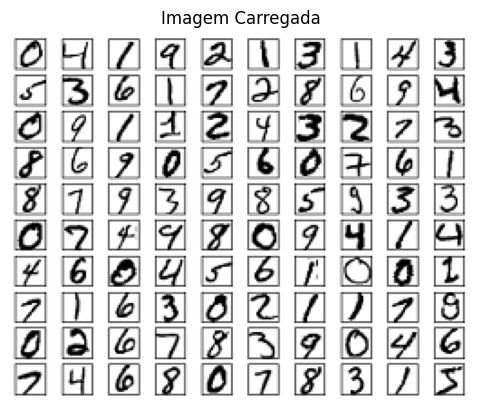

Matriz de pixels da imagem:
[[[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 ...

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]]


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

url = "https://www.deeplearningbook.com.br/wp-content/uploads/2017/12/mnist_100_digits.png"

# Fazer o download da imagem
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Converter a imagem para matriz NumPy
img_array = np.array(img)

# Exibir a imagem
plt.imshow(img_array)
plt.axis('off')
plt.title('Imagem Carregada')
plt.show()

# Exibir a matriz de pixels
print("Matriz de pixels da imagem:")
print(img_array)


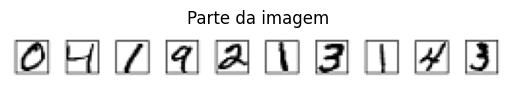

In [3]:
part_img = img_array[0:100][0:23]
plt.imshow(part_img)
plt.axis('off')
plt.title('Parte da imagem')
plt.show()

# Neurônios

In [4]:
import numpy as np

def neuron(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

inputs = np.array([1.0, 2.0])
weights = np.array([0.5, -1.5])
bias = 0.1

output = neuron(inputs, weights, bias)
print("Output:", output)

Output: -2.4


In [5]:
import numpy as np

class SimpleNeuron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, inputs):
        self.inputs = inputs
        self.output = self.sigmoid(np.dot(inputs, self.weights) + self.bias)
        return self.output

    def backward(self, target):
        error = target - self.output
        delta = error * self.sigmoid_derivative(self.output)
        self.weights += self.learning_rate * delta * self.inputs
        self.bias += self.learning_rate * delta
        return error

    def train(self, X, y, epochs=10000):
        for epoch in range(epochs):
            total_error = 0
            for inputs, target in zip(X, y):
                self.forward(inputs)
                error = self.backward(target)
                total_error += error**2
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Error: {total_error:.4f}")


In [6]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])  # Saídas esperadas para OR lógico

In [7]:
SimpleNeuron(2).train(X, y)

Epoch 0, Error: 1.3589
Epoch 100, Error: 0.5756
Epoch 200, Error: 0.3981
Epoch 300, Error: 0.2855
Epoch 400, Error: 0.2169
Epoch 500, Error: 0.1723
Epoch 600, Error: 0.1413
Epoch 700, Error: 0.1188
Epoch 800, Error: 0.1019
Epoch 900, Error: 0.0888
Epoch 1000, Error: 0.0784
Epoch 1100, Error: 0.0700
Epoch 1200, Error: 0.0631
Epoch 1300, Error: 0.0574
Epoch 1400, Error: 0.0525
Epoch 1500, Error: 0.0483
Epoch 1600, Error: 0.0447
Epoch 1700, Error: 0.0416
Epoch 1800, Error: 0.0389
Epoch 1900, Error: 0.0364
Epoch 2000, Error: 0.0343
Epoch 2100, Error: 0.0323
Epoch 2200, Error: 0.0306
Epoch 2300, Error: 0.0290
Epoch 2400, Error: 0.0276
Epoch 2500, Error: 0.0263
Epoch 2600, Error: 0.0251
Epoch 2700, Error: 0.0240
Epoch 2800, Error: 0.0230
Epoch 2900, Error: 0.0221
Epoch 3000, Error: 0.0212
Epoch 3100, Error: 0.0204
Epoch 3200, Error: 0.0197
Epoch 3300, Error: 0.0190
Epoch 3400, Error: 0.0184
Epoch 3500, Error: 0.0177
Epoch 3600, Error: 0.0172
Epoch 3700, Error: 0.0166
Epoch 3800, Error: 0.016

# Images

In [8]:
from torchvision import datasets

mnist = datasets.MNIST(root='./data', train=True, download=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 509kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.02MB/s]


In [9]:
print("Tamanho dos dados de treino:", len(mnist.train_data))
print("Shape:", mnist.train_data[0].shape)
print("Tipo:", type(mnist.train_data[0]), "\n")

Tamanho dos dados de treino: 60000
Shape: torch.Size([28, 28])
Tipo: <class 'torch.Tensor'> 



/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [10]:
mnist.data[0].shape

torch.Size([28, 28])

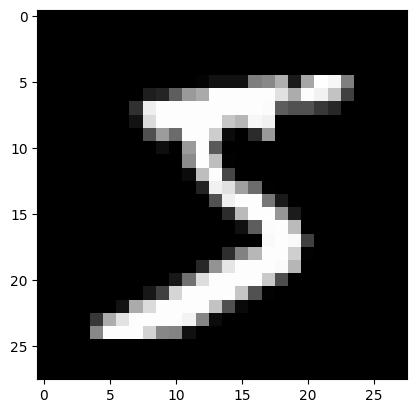

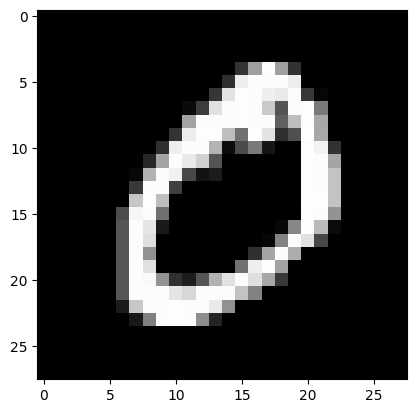

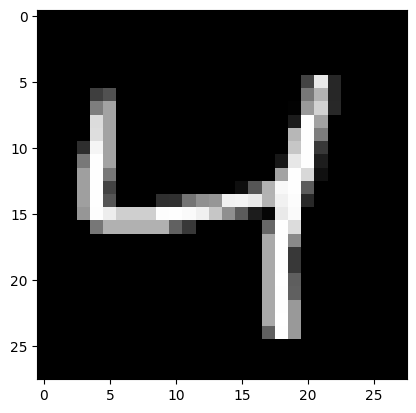

In [11]:
for i in range(3):
  plt.imshow(mnist.data[i], cmap='gray')
  plt.show()

# Reconhecendo digitos
URL livro: https://www.deeplearningbook.com.br/


marcação de capitulo: 18


In [12]:
import random
# vamos criar uma classe de rede
# sizes é um vetor que contém o tamanho das redes neurais em cada camada. ex: [2, 5, 6, 1]
class Network(object):
    def __init__(self,sizes):
      self.num_layers = len(sizes)
      self.sizes = sizes
      self.biases = [np.random.randn(y,1) for y in sizes[1:]]
      self.weights = [np.random.randn(y,x) for x,y in zip(sizes[:-1],sizes[1:])]

    def sigmoid(self,z):
      return 1.0/(1.0+np.exp(-z))

    def feedforward(self,a):
      for b,w in zip(self.biases,self.weights):
        a = self.sigmoid(np.dot(w,a)+b)
      return a

    def SGD(self,training_data,epochs,mini_batch_size,eta,test_data=None):
      training_data = list(training_data)
      n = len(training_data)

      if test_data:
        test_data = list(test_data)
        n_test = len(test_data)
      for j in range(epochs):
        random.shuffle(training_data)
        mini_batches = [training_data[k:k+mini_batch_size] for k in range(0,n,mini_batch_size)]
        for mini_batch in mini_batches:
          self.update_mini_batch(mini_batch,eta)

        if test_data:
          print("Epoch {} : {} / {}".format(j,self.evaluate(test_data),n_test))
        else:
          print("Epoch {} complete".format(j))

    def update_mini_batch(self, mini_batch, eta):
      nabla_b = [np.zeros(b.shape) for b in self.biases]
      nabla_w = [np.zeros(w.shape) for w in self.weights]
      for x, y in mini_batch:
        delta_nabla_b, delta_nabla_w = self.backprop(x, y)
        nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
        nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
      self.weights = [w-(eta/len(mini_batch))*nw
                      for w, nw in zip(self.weights, nabla_w)]
      self.biases = [b-(eta/len(mini_batch))*nb
                     for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
      nabla_b = [np.zeros(b.shape) for b in self.biases]
      nabla_w = [np.zeros(w.shape) for w in self.weights]

      activation = x

      activations = [x]
      zs = []
      for b, w in zip(self.biases, self.weights):
        z = np.dot(w, activation)+b
        zs.append(z)
        activation = self.sigmoid(z)
        activations.append(activation)

      delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(zs[-1])
      nabla_b[-1] = delta
      nabla_w[-1] = np.dot(delta, activations[-2].transpose())

      for l in range(2, self.num_layers):
        z = zs[-l]
        sp = self.sigmoid_prime(z)
        delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
        nabla_b[-l] = delta
        nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())

      return (nabla_b, nabla_w)

In [13]:
# exemplo de uso
rede1 = Network([2,3,1])
print("W:",rede1.weights)
print("B:",rede1.biases)

W: [array([[ 0.84875783,  1.19024645],
       [ 1.68314723, -1.00264092],
       [ 0.7749591 , -1.49319953]]), array([[ 1.61705305, -1.19513953, -0.47397408]])]
B: [array([[-1.45524798],
       [ 1.11031973],
       [ 1.44049032]]), array([[1.15178445]])]


## exemplo com modelo MLP
Já pronto para uso


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Pré-processamento dos dados
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 2. Definição do modelo MLP
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
        )


    def forward(self, x):
        return self.model(x)

# 3. Treinamento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(15):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} concluída. ", loss.item())

# 4. Avaliação
model.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Acurácia no teste: {100. * correct / len(test_loader.dataset):.2f}%")


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.88MB/s]


Epoch 1 concluída.  0.13383923470973969
Epoch 2 concluída.  0.1560772955417633
Epoch 3 concluída.  0.013935812748968601
Epoch 4 concluída.  0.08180617541074753
Epoch 5 concluída.  0.030983148142695427
Epoch 6 concluída.  0.010821742005646229
Epoch 7 concluída.  0.12569071352481842
Epoch 8 concluída.  0.00794041808694601
Epoch 9 concluída.  0.010182592086493969
Epoch 10 concluída.  0.0018290746957063675
Epoch 11 concluída.  0.05552707239985466
Epoch 12 concluída.  0.005288365762680769
Epoch 13 concluída.  0.022591933608055115
Epoch 14 concluída.  0.015631236135959625
Epoch 15 concluída.  0.00095022824825719
Acurácia no teste: 98.39%


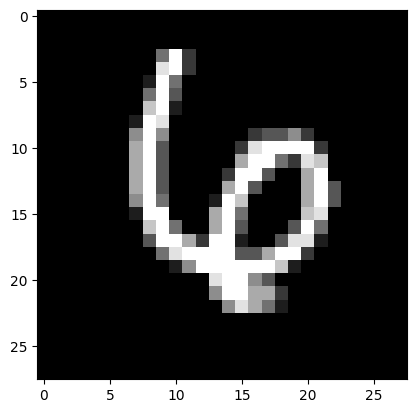

Dígito previsto: 6


In [51]:
# apresenta erros no index 720, 729

index = 22
plt.imshow(dataset.data[index], cmap='gray')
plt.show()

with torch.no_grad():
    output = model(dataset.data[index].unsqueeze(0).float())
    pred = output.argmax(dim=1)
    print(f"Dígito previsto: {pred.item()}")


# faces

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()

In [ ]:
plt.imshow(faces.images[2], cmap="gray")
plt.show()